**EXPLORATORY DATA ANALYSIS ON PCOS DATASET**

This analysis explores the relationships between factors such as BMI, testosterone levels, and menstrual irregularity with PCOS diagnosis.

Here we imported the libraries and uploaded the dataset 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv("E:/project_datasets&nbs/pcos_dataset.csv")

These function display the first and last five rows of the dataset

In [4]:
dataset.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [5]:
dataset.tail()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
995,34,18.4,1,95.7,23,0
996,45,28.9,1,28.5,7,0
997,37,28.3,0,32.4,28,0
998,41,27.3,0,95.6,9,0
999,22,21.9,1,78.9,7,0


This fucntions tells us about the columns.
It also shows if there are any NULL values and the data types of the columns

In [6]:
dataset.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


Now we check for any NULL values in the columns

In [7]:
dataset.isnull().sum()

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64

Now we check for duplicate values if any

In [8]:
dataset.duplicated().sum()

np.int64(0)

THe describe function gives us the mean and standard deviation of the numerical columns (wont be provided for columns containing strings or textual values)
It also helps us identify outliers by using Q1, Q3 and finding the Inter Quartile Range

In [9]:
dataset.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.771000,26.38700,0.530000,60.159500,17.469000,0.199000
std,8.463462,4.93554,0.499349,23.160204,7.069301,0.399448
min,18.000000,18.10000,0.000000,20.000000,5.000000,0.000000
25%,24.000000,21.90000,0.000000,41.700000,12.000000,0.000000
50%,32.000000,26.40000,1.000000,60.000000,18.000000,0.000000
75%,39.000000,30.50000,1.000000,80.300000,23.250000,0.000000
max,45.000000,35.00000,1.000000,99.800000,29.000000,1.000000


In [10]:
dataset.dtypes

Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64
dtype: object

Now we check for any outliers in the columns BMI and Testosterone Level.

<Axes: ylabel='BMI'>

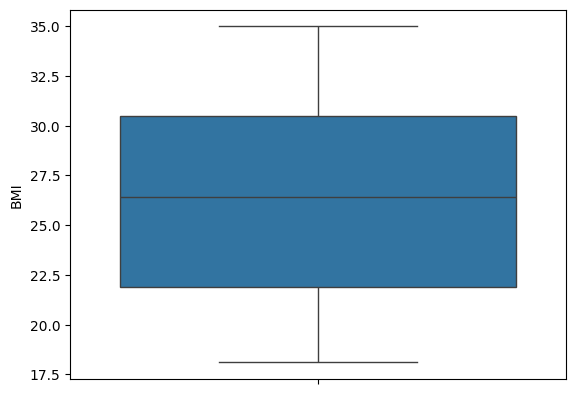

In [11]:
sns.boxplot(y= 'BMI', data=dataset)

<Axes: ylabel='Testosterone_Level(ng/dL)'>

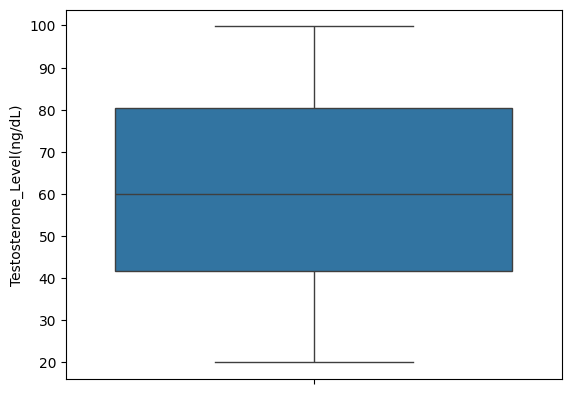

In [12]:
sns.boxplot(y= 'Testosterone_Level(ng/dL)', data=dataset)

Now we check how many have Menstrual Irregularity
We will be using it to check how much it affects PCOS

<Axes: xlabel='Menstrual_Irregularity', ylabel='count'>

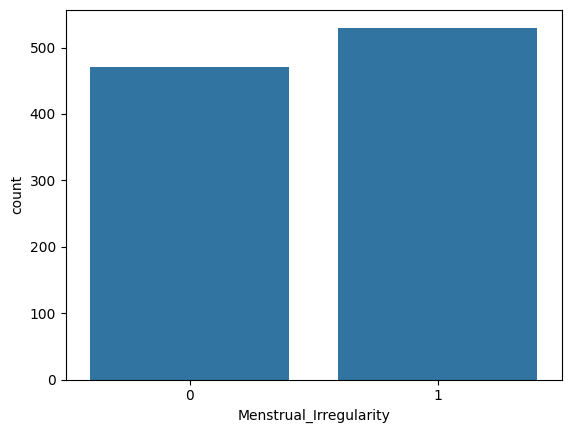

In [13]:
sns.countplot(x= 'Menstrual_Irregularity', data=dataset)

<Axes: xlabel='BMI', ylabel='Count'>

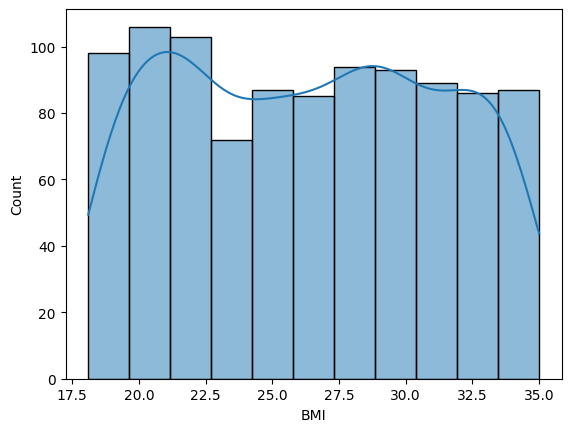

In [14]:
sns.histplot(dataset['BMI'], kde=True)

We plotted BMI and Testosterone Level above and below respectively. Here we wanted to see how many women fall under which category of BMI and how much level of Testosterone is present in their bodies

<Axes: xlabel='Testosterone_Level(ng/dL)', ylabel='Count'>

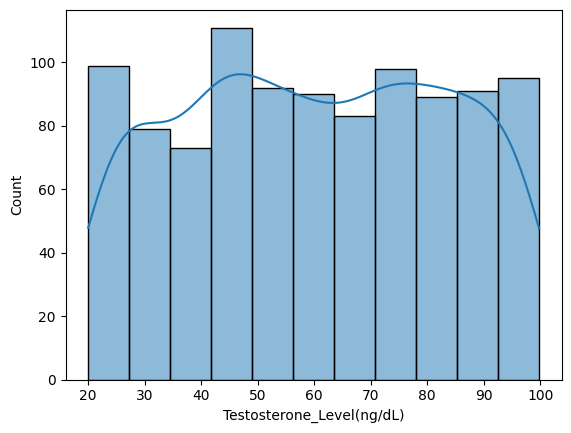

In [15]:
sns.histplot(dataset['Testosterone_Level(ng/dL)'], kde=True)

**Beginning from here we will be plotting different graphs of all the columns with the PCOS_Diagnosis one to check which symptom may be linked with PCOS**

Here the graph tells us that out of all the women who have irregular menstrual cycles, a bigger amount of women are diagnosed with PCOS.

<Axes: xlabel='Menstrual_Irregularity', ylabel='count'>

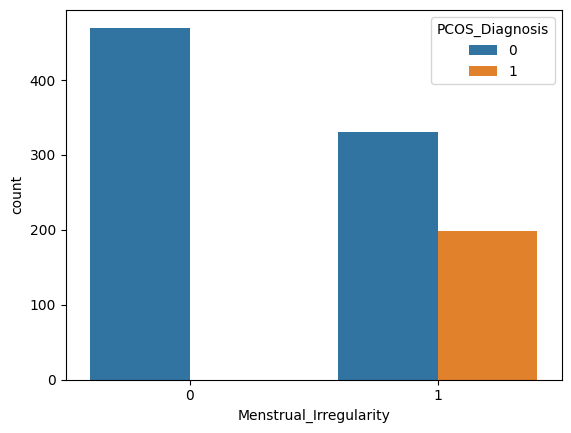

In [16]:
sns.countplot(x='Menstrual_Irregularity', hue='PCOS_Diagnosis', data=dataset)

This graph indicates the same thing as the one above it. It tells us that a bigger proportion of women who have irregular menstrual cycles are diagnosed with PCOS.

<Axes: xlabel='Menstrual_Irregularity'>

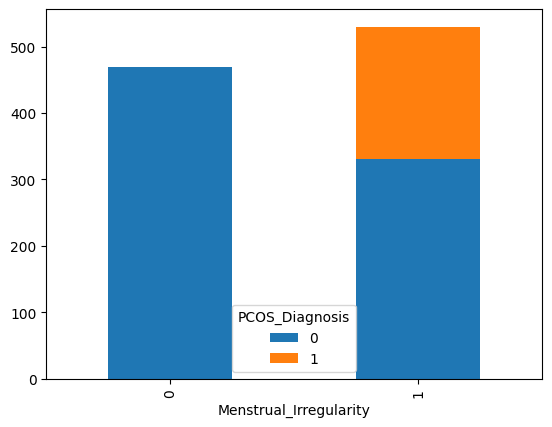

In [17]:
pd.crosstab(dataset['Menstrual_Irregularity'], dataset['PCOS_Diagnosis']).plot(kind='bar', stacked=True)

Now we check how PCOS is related to BMI. The graph below indicates that women who have a higher BMI can be diagnosed with PCOS. Although PCOS is also present across multiple BMI ranges.

<Axes: xlabel='PCOS_Diagnosis', ylabel='BMI'>

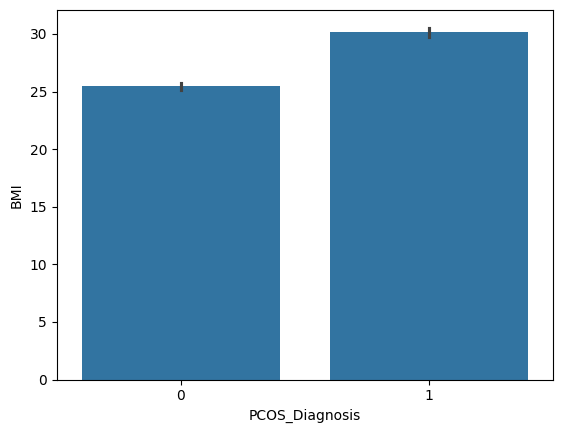

In [18]:
sns.barplot(x='PCOS_Diagnosis', y='BMI', data=dataset)

The graph below shows that PCOS diagnoses are concentrated within reproductive age groups.

<Axes: xlabel='PCOS_Diagnosis', ylabel='Age'>

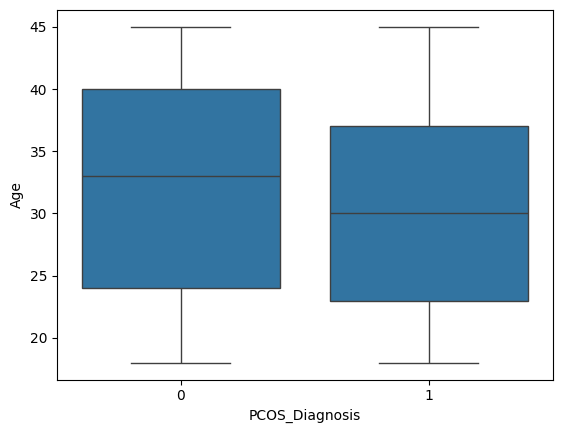

In [19]:
sns.boxplot(x='PCOS_Diagnosis', y='Age', data=dataset)

The following graph indicates that if the Testosterone (a male hormone) levels are seemingly high in a females body, it can increase the risk of her being diagnosed with PCOS.

<Axes: xlabel='PCOS_Diagnosis', ylabel='Testosterone_Level(ng/dL)'>

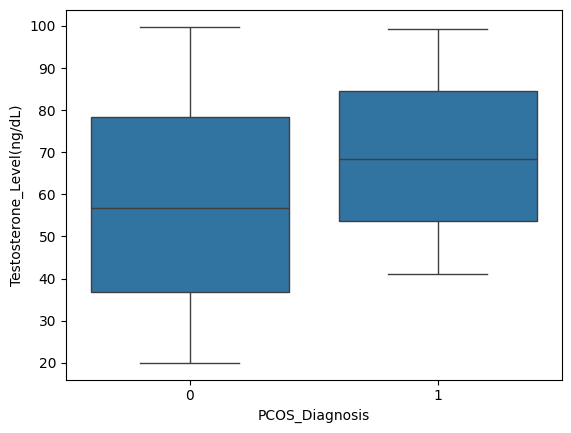

In [20]:
sns.boxplot(x='PCOS_Diagnosis', y='Testosterone_Level(ng/dL)', data=dataset)

Antral Follicle Count checks the count of eggs in the women's ovary using an ultrasound and if the count is above a certain amount, it indicates that the women can be diagnosed with PCOS.

 The following graph indicates that if the count is higher, then the women can be said to have PCOS.

<Axes: xlabel='PCOS_Diagnosis', ylabel='Antral_Follicle_Count'>

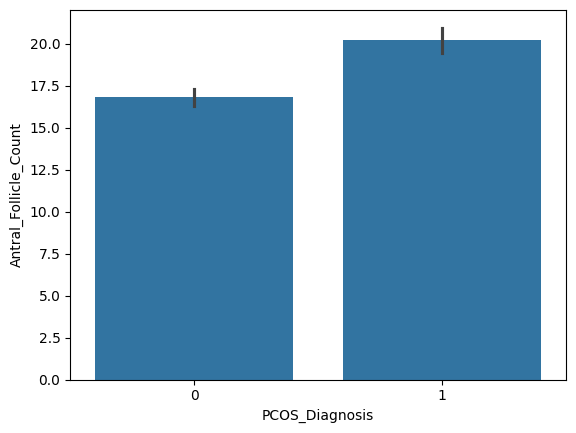

In [21]:
sns.barplot(x='PCOS_Diagnosis', y='Antral_Follicle_Count', data=dataset)

In the following graph we are checking if the increased testosterone levels somehow affected the BMI of a person which in exchange leads to PCOS.

 You can see that as testosterone levels and the BMI reach a higher level or amount, the risk of being diagnoesd with PCOS also increases.

<Axes: xlabel='BMI', ylabel='Testosterone_Level(ng/dL)'>

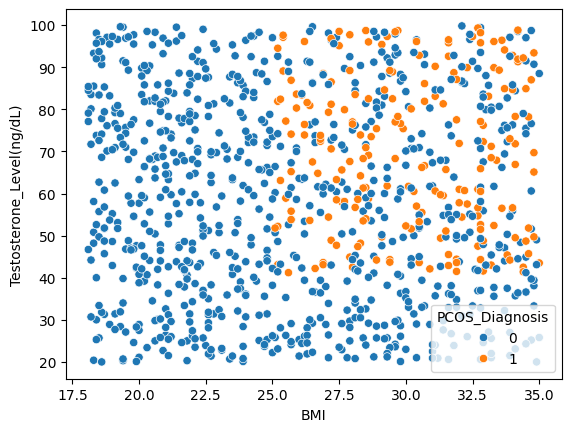

In [22]:
sns.scatterplot(x='BMI', y='Testosterone_Level(ng/dL)', hue='PCOS_Diagnosis', data=dataset)

The following graph shows that menstrual irregularity can happen at any BMI using which we conclude that having a higher BMI doesnt actually refer to having an irregular menstrual cycle.

<Axes: xlabel='Menstrual_Irregularity', ylabel='BMI'>

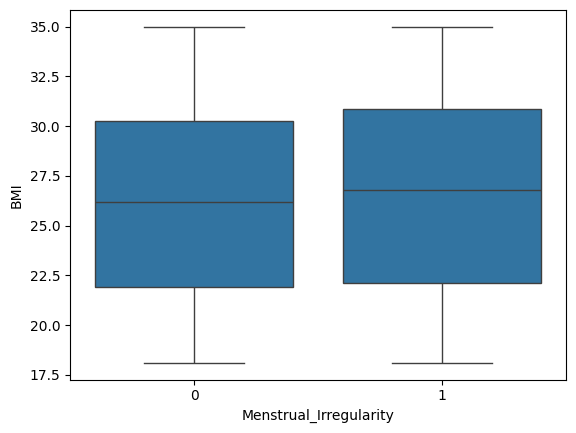

In [23]:
sns.boxplot(x='Menstrual_Irregularity', y='BMI', data=dataset)

The graph below indicates that with increased levels of testosterone in a female body, the women can be diagnosed with mestrual irregularity

<Axes: xlabel='Menstrual_Irregularity', ylabel='Testosterone_Level(ng/dL)'>

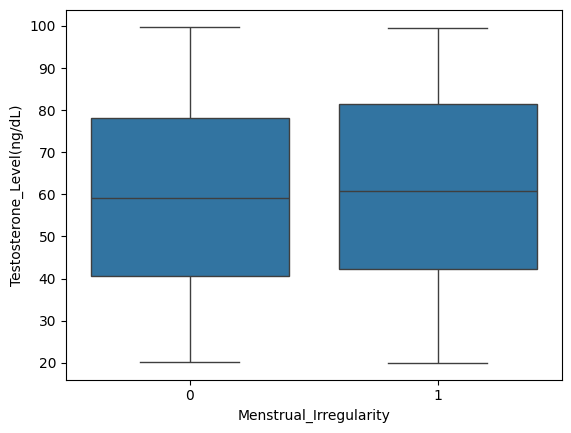

In [24]:
sns.boxplot(x='Menstrual_Irregularity', y='Testosterone_Level(ng/dL)', data=dataset)

An increased amount of Antral Follicle count can associate irregular menstrual cycle.

<Axes: xlabel='Menstrual_Irregularity', ylabel='Antral_Follicle_Count'>

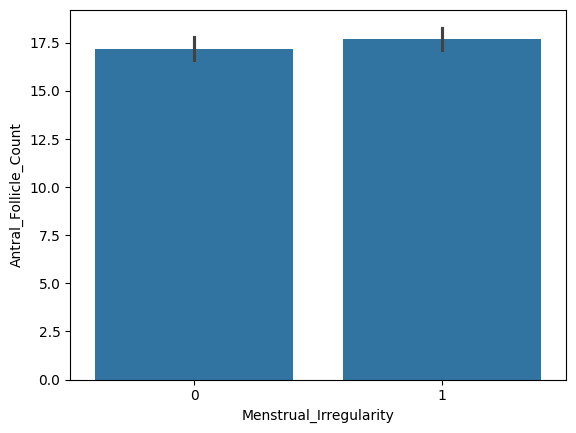

In [25]:
sns.barplot(x='Menstrual_Irregularity', y='Antral_Follicle_Count', data=dataset)

The line plotted shows that testosterone levels do affect antral follicle count but not that drastically.

<Axes: xlabel='Testosterone_Level(ng/dL)', ylabel='Antral_Follicle_Count'>

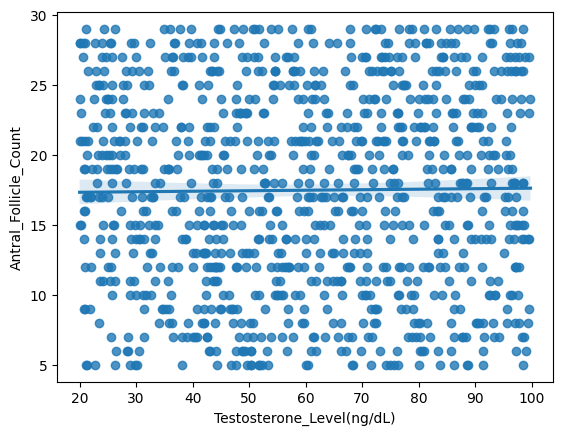

In [26]:
sns.regplot(x='Testosterone_Level(ng/dL)', y='Antral_Follicle_Count', data=dataset)

The following graph shows that if antral follicle count is higher than it is supposed to be and if testosterone levels are also greater, the risk of being diagnosed with PCOS increases.

<Axes: xlabel='Testosterone_Level(ng/dL)', ylabel='Antral_Follicle_Count'>

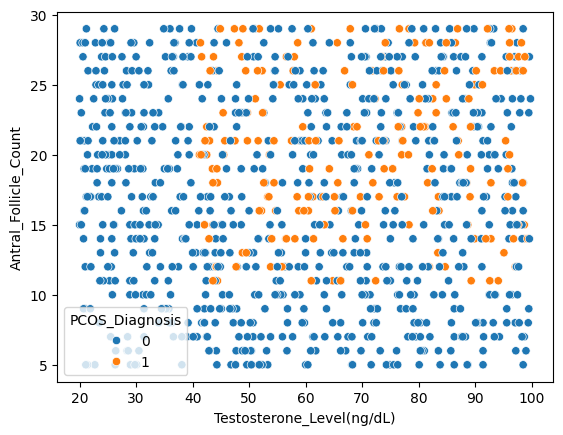

In [27]:
sns.scatterplot(x='Testosterone_Level(ng/dL)', y='Antral_Follicle_Count', hue='PCOS_Diagnosis', data=dataset)

**Correlation Heatmap**


The following Heatmap indicates that PCOS diagnosis shows strong positive correlation with testosterone levels and antral follicle count, while weaker correlations exist with age.

<Axes: >

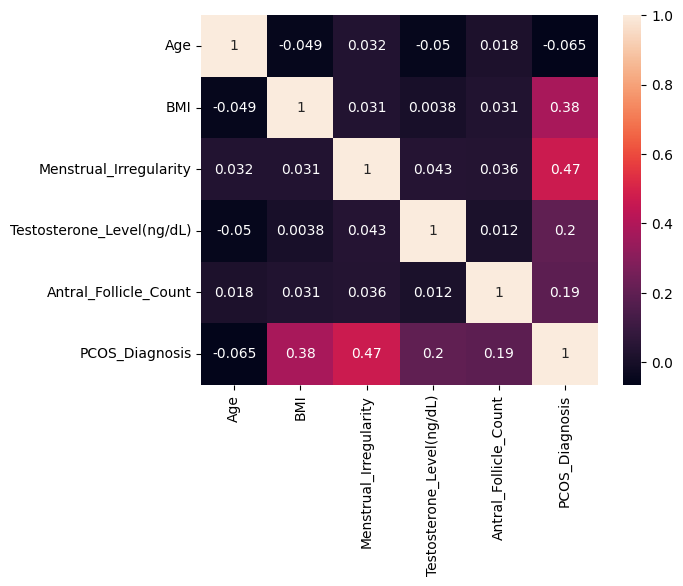

In [28]:
sns.heatmap(dataset.select_dtypes(include=np.number).corr(), annot=True)

**INSIGHTS**

1. Mestrual Irregualrity shows strong association with PCOS diagnosis.
2. Elevated testosterone levels demonstrate strong positive correlation with PCOS.
3. Higher antral follicle count appears as one of the strongest indicators linked to PCOS.
4. BMI shows moderate association but cannot alone be the factor that affects PCOS.
5. PCOS diagnosis appears influenced by multiple interacting physiological factors rather than a single variable.